# Inverse Diagnostic Demo

Этот notebook использует только публичный API `run_inverse_diagnostic_cycle(...)` и notebook-loader без дублирования бизнес-логики.

In [1]:
from pathlib import Path
import pandas as pd

from hidden_patterns_combat.app.inverse_diagnostic_cycle import run_inverse_diagnostic_cycle
from hidden_patterns_combat.ui.inverse_notebook import (
    display_inverse_plots,
    display_inverse_report,
    load_inverse_artifacts,
)


In [2]:
def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hidden_patterns_combat").exists():
            return candidate
    return start

repo_root = _find_repo_root(Path.cwd())
input_path = repo_root / "data" / "raw" / "episodes.xlsx"
base_output_dir = repo_root / "artifacts" / "inverse_diagnostic_runs"

if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

isolated_run = True
cleanup_mode = "none"


In [3]:
def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hidden_patterns_combat").exists():
            return candidate
    return start

repo_root = _find_repo_root(Path.cwd())
input_path = "data/raw/episodes.xlsx"
base_output_dir = repo_root / "artifacts" / "inverse_diagnostic_runs"

print(f"Using input (logical): {input_path}")
print(f"Using output base: {base_output_dir}")

result = run_inverse_diagnostic_cycle(
    input_path=input_path,
    output_dir=base_output_dir,
    isolated_run=isolated_run,
    cleanup_mode=cleanup_mode,
    retrain=True,
    n_states=3,
    topology_mode="left_to_right",
    generate_plots=True,
    verbose=True,
)

final_output_dir = Path(result.final_output_dir)
artifacts = load_inverse_artifacts(
    final_output_dir,
    expected_run_id=result.run_id,
    expected_run_fingerprint=result.run_fingerprint,
)


Using input (logical): data/raw/episodes.xlsx
Using output base: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_runs
[cleanup] mode=none, previous artifacts are preserved.
[1/7] Preprocessing input workbook...
[2/7] Building canonical observations and episode table...
[3/7] Training/loading inverse diagnostic HMM...
[4/7] Viterbi decoding and posterior profile...
[5/7] Rendering report and plots...
[6/7] Finalizing outputs...
[7/7] Inverse diagnostic cycle completed.


## Current Run Metadata


In [4]:
try:
    from IPython.display import Markdown, display

    manifest = artifacts.run_manifest or {}
    warning_lines = "\n".join(f"- {w}" for w in artifacts.loader_warnings[:20])
    if not warning_lines:
        warning_lines = "- none"

    display(Markdown(
        f"""
- run_id: `{result.run_id}`
- final_output_dir: `{result.final_output_dir}`
- run_manifest_path: `{result.run_manifest_path}`
- started_at: `{manifest.get('started_at', 'n/a')}`
- finished_at: `{manifest.get('finished_at', 'n/a')}`
- input_file: `{manifest.get('input_file_name', 'n/a')}`
- key warnings:
{warning_lines}
"""
    ))
except Exception:
    print("run_id:", result.run_id)
    print("final_output_dir:", result.final_output_dir)
    print("run_manifest_path:", result.run_manifest_path)
    print("started_at:", artifacts.run_manifest.get("started_at", "n/a"))
    print("finished_at:", artifacts.run_manifest.get("finished_at", "n/a"))
    print("input_file:", artifacts.run_manifest.get("input_file_name", "n/a"))
    print("warnings:")
    for warning in artifacts.loader_warnings[:20]:
        print("-", warning)



- run_id: `20260416T141200Z_inverse_diagnostic`
- final_output_dir: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_runs/20260416T141200Z_inverse_diagnostic`
- run_manifest_path: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_runs/20260416T141200Z_inverse_diagnostic/run_manifest.json`
- started_at: `2026-04-16T14:12:00Z`
- finished_at: `2026-04-16T14:12:23Z`
- input_file: `episodes.xlsx`
- key warnings:
- unsupported_finish_values: empty (csv has header but no rows) -> /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_runs/20260416T141200Z_inverse_diagnostic/diagnostics/unsupported_finish_values.csv


In [5]:
artifacts.artifact_status


,artifact_name,artifact_type,path,status,detail
0,unsupported_finish_values,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,empty,csv has header but no rows
1,episode_analysis,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=2892
2,metadata_extraction_summary,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=17
3,metadata_field_coverage,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=12
4,model_health_summary,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=22
5,observation_audit,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=27
6,observation_mapping_crosstab,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=10
7,quality_diagnostics,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=9
8,raw_finish_signal_summary,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=6
9,report_markdown,text,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,chars=20843


In [6]:
display_inverse_report(artifacts.report_markdown)


# Inverse Diagnostic Report

## 1) Executive summary
- Rows analyzed: 2892
- Unique observed classes: ['arm_submission', 'hold', 'leg_submission', 'no_score', 'unknown', 'zap_n', 'zap_r', 'zap_t']
- Mean posterior confidence: 0.938
- semantic_assignment_quality: partial
- Observed layer is mostly no_score.
- Unsupported score values detected: [8, 6, 5, 9, 10, 12].
- Sequence segmentation is surrogate-based.
- State semantics are not fully stabilized; strong KFV/VUP interpretation is unsafe.
- Hidden transition dynamics are close to degenerate (self-loops dominate).
- All hidden states are maneuvering-like; semantic contrast is weak.

## 2) Observed layer quality
- direct_finish_signal share: 0.098
- inferred_from_score share: 0.013
- no_score_rule share: 0.881
- ambiguous share: 0.008
- unknown share: 0.000
- direct observations available: True
- observed layer mostly no_score: True

## 3) Raw finish/action signal audit
- candidate finish/action columns: 6
- supported finish columns: ['outcomes__finish_action_01_02', 'outcomes__finish_action_02_03', 'outcomes__finish_action_03_04', 'outcomes__finish_action_04_05', 'outcomes__finish_action_05_06', 'outcomes__finish_action_06_07']
- supported finish columns with positive values: ['outcomes__finish_action_01_02', 'outcomes__finish_action_02_03', 'outcomes__finish_action_03_04', 'outcomes__finish_action_04_05', 'outcomes__finish_action_05_06', 'outcomes__finish_action_06_07']
- mapped finish positive rows: 306
- unmapped finish positive rows: 0
- mapping gap detected: False
- unsupported finish columns with positive values: []
- unsupported finish values rows: 0
- unsupported score values: [8, 6, 5, 9, 10, 12]
- direct finish match class counts: {'zap_n': 102, 'zap_r': 87, 'zap_t': 51, 'leg_submission': 18, 'hold': 18, 'arm_submission': 6}
- hold/arm/leg presence: {'hold': {'columns': ['outcomes__finish_action_04_05'], 'positive_rows': 36, 'present_in_raw': True}, 'arm_submission': {'columns': ['outcomes__finish_action_05_06'], 'positive_rows': 9, 'present_in_raw': True}, 'leg_submission': {'columns': ['outcomes__finish_action_06_07'], 'positive_rows': 24, 'present_in_raw': True}}

## 4) Metadata and time extraction quality
- informative metadata fields: ['athlete_name', 'athlete_id', 'sheet_name', 'episode_id', 'episode_time_sec', 'pause_time_sec', 'score', 'sequence_id']
- non-informative metadata fields: ['weight_class', 'opponent_name', 'tournament_name', 'event_date']
- episode_time informative: True
- pause_time informative: True
- weight_class informative: False
- segmentation support: {'readiness': 'partial', 'explicit_sequence_field_available': False, 'explicit_sequence_source_column': None, 'sequence_id_informative': True, 'context_fields_available': [], 'context_fields_missing': ['weight_class', 'opponent_name', 'tournament_name', 'event_date'], 'context_fields_informative': [], 'context_fields_non_informative': ['weight_class', 'opponent_name', 'tournament_name', 'event_date']}
- temporal modeling support: {'readiness': 'strong', 'episode_time_informative': True, 'pause_time_informative': True}

### Critical Metadata/Time Fields
           field  found                source_column  missing_share  zero_share  informative                                                                                                                                               sample_values
episode_time_sec   True metadata__episode_attr_02_03            0.0    0.000000         True                                                                                                                                            34.0, 29.0, 31.0
  pause_time_sec   True metadata__episode_attr_03_04            0.0    0.103734         True                                                                                                                                              7.0, 8.0, 10.0
     sequence_id   True                          NaN            0.0         NaN         True 48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00, 48::Рузанов А.О.::w=::opp=::tour=::date=::block_00, 48::Лушников А.О.::w=::opp=::tour=::date=::block_00
      event_date  False                          NaN            1.0         NaN        False                                                                                                                                                            
   opponent_name  False                          NaN            1.0         NaN        False                                                                                                                                                            
 tournament_name  False                          NaN            1.0         NaN        False                                                                                                                                                            
    weight_class  False                          NaN            1.0         NaN        False                                                                                                                                                            

### Metadata Field Coverage (preview)
           field  informative                source_column  missing_share  zero_share
      athlete_id         True       metadata__athlete_name            0.0         NaN
    athlete_name         True       metadata__athlete_name            0.0         NaN
      episode_id         True metadata__episode_attr_01_02            0.0         NaN
episode_time_sec         True metadata__episode_attr_02_03            0.0    0.000000
  pause_time_sec         True metadata__episode_attr_03_04            0.0    0.103734
           score         True              outcomes__score            0.0    0.881743
     sequence_id         True                          NaN            0.0         NaN
      sheet_name         True           metadata__sheet_05            0.0         NaN
      event_date        False                          NaN            1.0         NaN
   opponent_name        False                          NaN            1.0         NaN
 tournament_name        False                          NaN            1.0         NaN
    weight_class        False                          NaN            1.0         NaN

## 5) Sequence segmentation quality
- explicit/surrogate/fallback shares: 0.000 / 1.000 / 0.000
- high/medium/low sequence quality shares: 0.000 / 1.000 / 0.000
- explicit sequence fields checked: ['metadata__sequence_id', 'metadata__sequence', 'sequence_id', 'sequence', 'metadata__bout_id', 'metadata__bout_number', 'metadata__bout_num', 'metadata__bout', 'metadata__bout_no', 'metadata__bout_sequence', 'metadata__fight_number', 'metadata__fight_no', 'metadata__match_id', 'metadata__match_number', 'metadata__match_no', 'metadata__fight_id', 'bout_id', 'bout', 'bout_number', 'bout_num', 'bout_no', 'bout_sequence', 'bout_seq', 'match_id', 'match_no', 'match_num', 'match_number', 'match', 'fight_id', 'fight_number', 'fight_no', 'fight', 'номер_схватки', 'номер поединка', 'номер схватки', 'схватка', 'поединок']
- explicit sequence source column: None
- explicit sequence fields missing: ['metadata__sequence_id', 'metadata__sequence', 'sequence_id', 'sequence', 'metadata__bout_id', 'metadata__bout_number', 'metadata__bout_num', 'metadata__bout', 'metadata__bout_no', 'metadata__bout_sequence', 'metadata__fight_number', 'metadata__fight_no', 'metadata__match_id', 'metadata__match_number', 'metadata__match_no', 'metadata__fight_id', 'bout_id', 'bout', 'bout_number', 'bout_num', 'bout_no', 'bout_sequence', 'bout_seq', 'match_id', 'match_no', 'match_num', 'match_number', 'match', 'fight_id', 'fight_number', 'fight_no', 'fight', 'номер_схватки', 'номер поединка', 'номер схватки', 'схватка', 'поединок']
- surrogate_based_segmentation: True
- surrogate reason counts: {'surrogate_episode_only': 2892}
- suspicious potential multi-bout sequences: 0
- potential multi-bout ids preview: []

## 6) Model health
- self_transition_share: 0.995
- top_self_transition_share: 0.926
- effective_state_usage: 0.667
- degenerate_transition_warning: True
- low_information_observed_layer_warning: False
- maneuvering_only_state_profile_warning: True

## 7) State semantics quality
- semantic_assignment_quality: partial
- semantic_assignment: {'S1': 0}
- semantic_confidence: {'S1': 0.5329346121887106, 'S2': 0.0, 'S3': 0.0}
- confirmed states: ['S1']
- assigned but unconfirmed states: []
- all assigned states: ['S1']
- Семантика подтверждается только для S1; интерпретация остальных состояний не стабилизировалась. Дополнительно: все состояния имеют maneuvering-like profile.

 hidden_state hidden_state_name  episodes_count  confidence    key_link
            0                S1             183    0.752607 maneuvering
            1           state_0            2661    0.950263 maneuvering
            2           state_2              48    0.965732 maneuvering

## 8) Recommendation
- Profile: cautious profile
- Семантика подтверждена только для части состояний (S1); для остальных состояний содержательная интерпретация пока неустойчива. Метрики профиля: coverage=0.92, high_conf=0.94, mean_posterior=0.87, self_transition_share=1.00.

## 9) Limitations
- Explicit bout/sequence ids were not detected; segmentation is surrogate-based.
- Hidden-state transitions are close to degenerate (very high self-loop share or low effective state usage).
- Most rows rely on surrogate sequence segmentation.
- Some bout-context fields are missing; surrogate segmentation may merge multiple bouts.
- State profiles collapse to maneuvering-like links; semantic contrast is weak.
- State semantics are only partially confirmed; avoid hard interpretation for unconfirmed states.
- Suspicious sequences were detected; inspect suspicious_sequences.csv.
- Unsupported non-zero score values were found; these rows map to unknown without direct finish signals.
- Weight class is missing or non-informative in canonical episodes.
- event_date is unavailable; sequence segmentation cannot use this marker.
- opponent_name is unavailable; sequence segmentation cannot use this marker.
- tournament_name is unavailable; sequence segmentation cannot use this marker.

## 10) Concrete next actions
1. Добавить правила для unsupported score values или подтвердить, что они должны оставаться unknown.
2. Подтвердить источник weight_class; не использовать эвристическую подмену без явного признака колонки.
3. Добавить явный bout/sequence marker на уровне ingest или metadata export, чтобы уйти от surrogate-only segmentation.
4. Перед повторным обучением увеличить информативность observed layer и разнообразие последовательностей.
5. Повторно оценить semantic assignment после усиления observed/metadata/segmentation слоев.

### Episode Preview
episode_id                                          sequence_id observed_zap_class observation_resolution_type observation_confidence_label      observation_quality_flag hidden_state_name  confidence
         1   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00              zap_r        direct_finish_signal                         high                ok_finish_rule           state_0    0.999963
         2   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999943
         3   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999910
         4   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999855
         1   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule                S1    0.914417
         2   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule                S1    0.853164
         3   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00              zap_n        direct_finish_signal                         high ok_finish_rule_score_mismatch                S1    0.778113
         4   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00            unknown                   ambiguous                          low      unknown_ambiguous_finish                S1    0.599318
         1  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998117
         2  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998116
         3  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998113
         4  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998109
         5  48::Лушников А.О.::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium                 ok_score_rule           state_0    0.998102
         6  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998095
         7  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998083
         8  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998063
         9  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998030
        10  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.997975
         1 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999245
         2 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999244
         3 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium                 ok_score_rule           state_0    0.999242
         4 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999239
         5 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999234
         6 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999227
         7 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999215
         8 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999195
         9 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999162
        10 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999107
         1   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         2   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         3   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         4   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999596
         5   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999595
         6   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00              zap_r        direct_finish_signal                         high ok_finish_rule_score_mismatch           state_0    0.999593
         7   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999590
         8   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999585
         9   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999578
        10   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999566
        11   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999546
        12   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999513

### Transition Preview
 from_state  to_state from_name to_name  count    share  is_self_loop
          1         1   state_0 state_0   2400 0.925926          True
          0         0        S1      S1    144 0.055556          True
          2         2   state_2 state_2     36 0.013889          True
          0         2        S1 state_2     12 0.004630         False

## 11) Run provenance / Reproducibility
- run_id: 20260416T141200Z_inverse_diagnostic
- input file: episodes.xlsx
- output dir: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_runs/20260416T141200Z_inverse_diagnostic
- started_at: 2026-04-16T14:12:00Z
- finished_at: 2026-04-16T14:12:22Z
- topology_mode: left_to_right
- model_mode: retrained
- mapping_version: observation_mapping_v2
- key warnings:
  - Unsupported non-zero score values were found; these rows map to unknown without direct finish signals.
  - Weight class is missing or non-informative in canonical episodes.
  - opponent_name is unavailable; sequence segmentation cannot use this marker.
  - tournament_name is unavailable; sequence segmentation cannot use this marker.
  - event_date is unavailable; sequence segmentation cannot use this marker.
  - Explicit bout/sequence ids were not detected; segmentation is surrogate-based.
  - Most rows rely on surrogate sequence segmentation.
  - Suspicious sequences were detected; inspect suspicious_sequences.csv.
  - Some bout-context fields are missing; surrogate segmentation may merge multiple bouts.
  - Hidden-state transitions are close to degenerate (very high self-loop share or low effective state usage).
  - State profiles collapse to maneuvering-like links; semantic contrast is weak.
  - State semantics are only partially confirmed; avoid hard interpretation for unconfirmed states.


### hidden_state_sequence

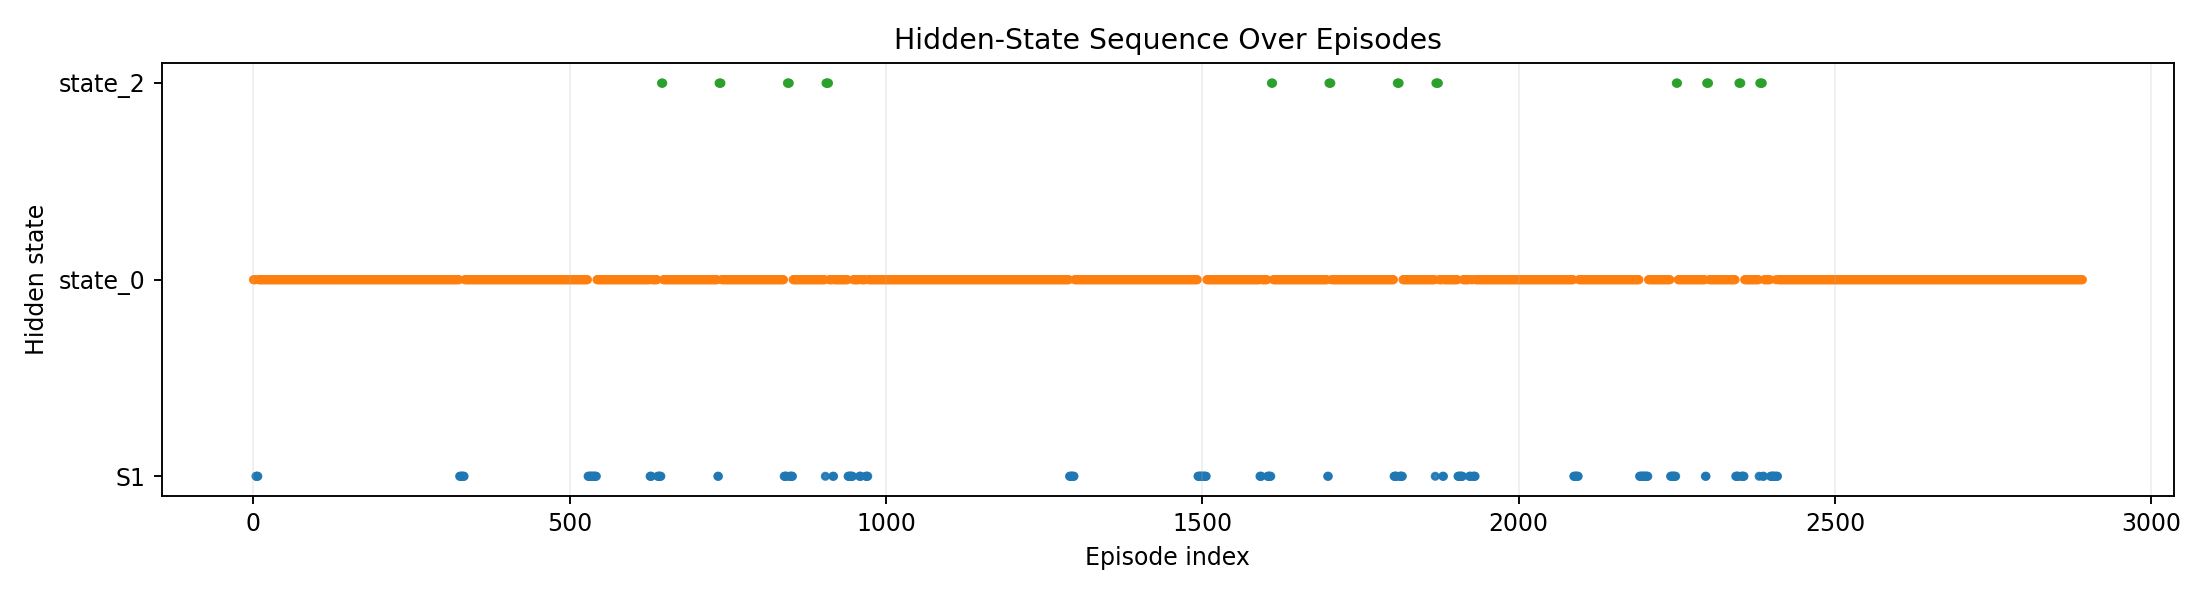

### state_probability_profile

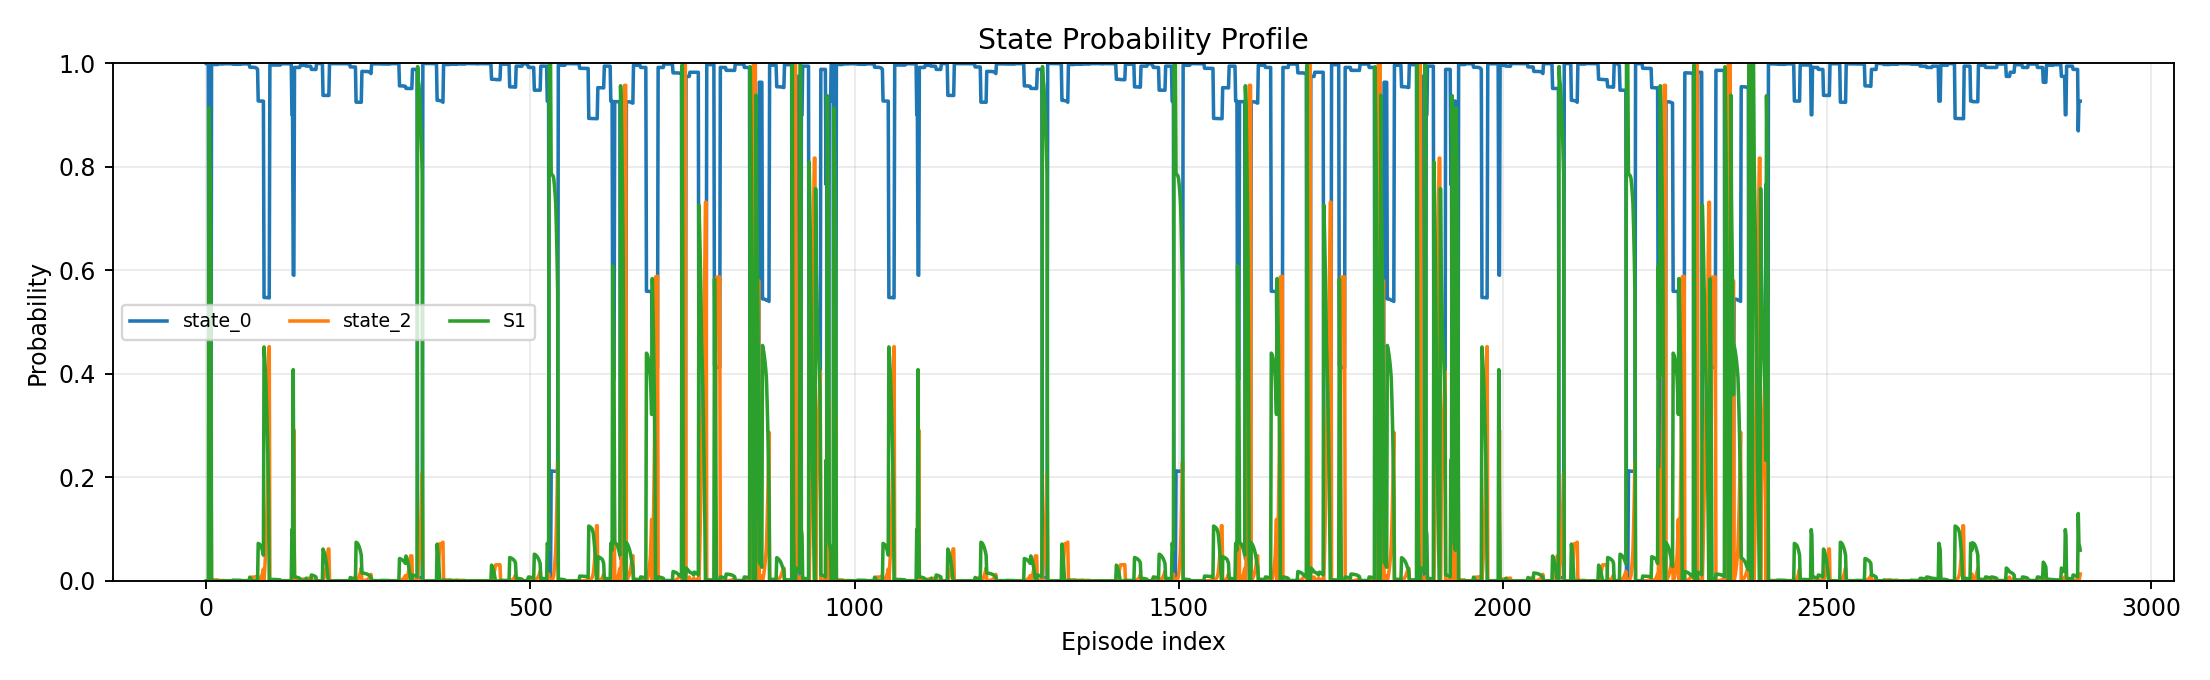

### transition_distribution

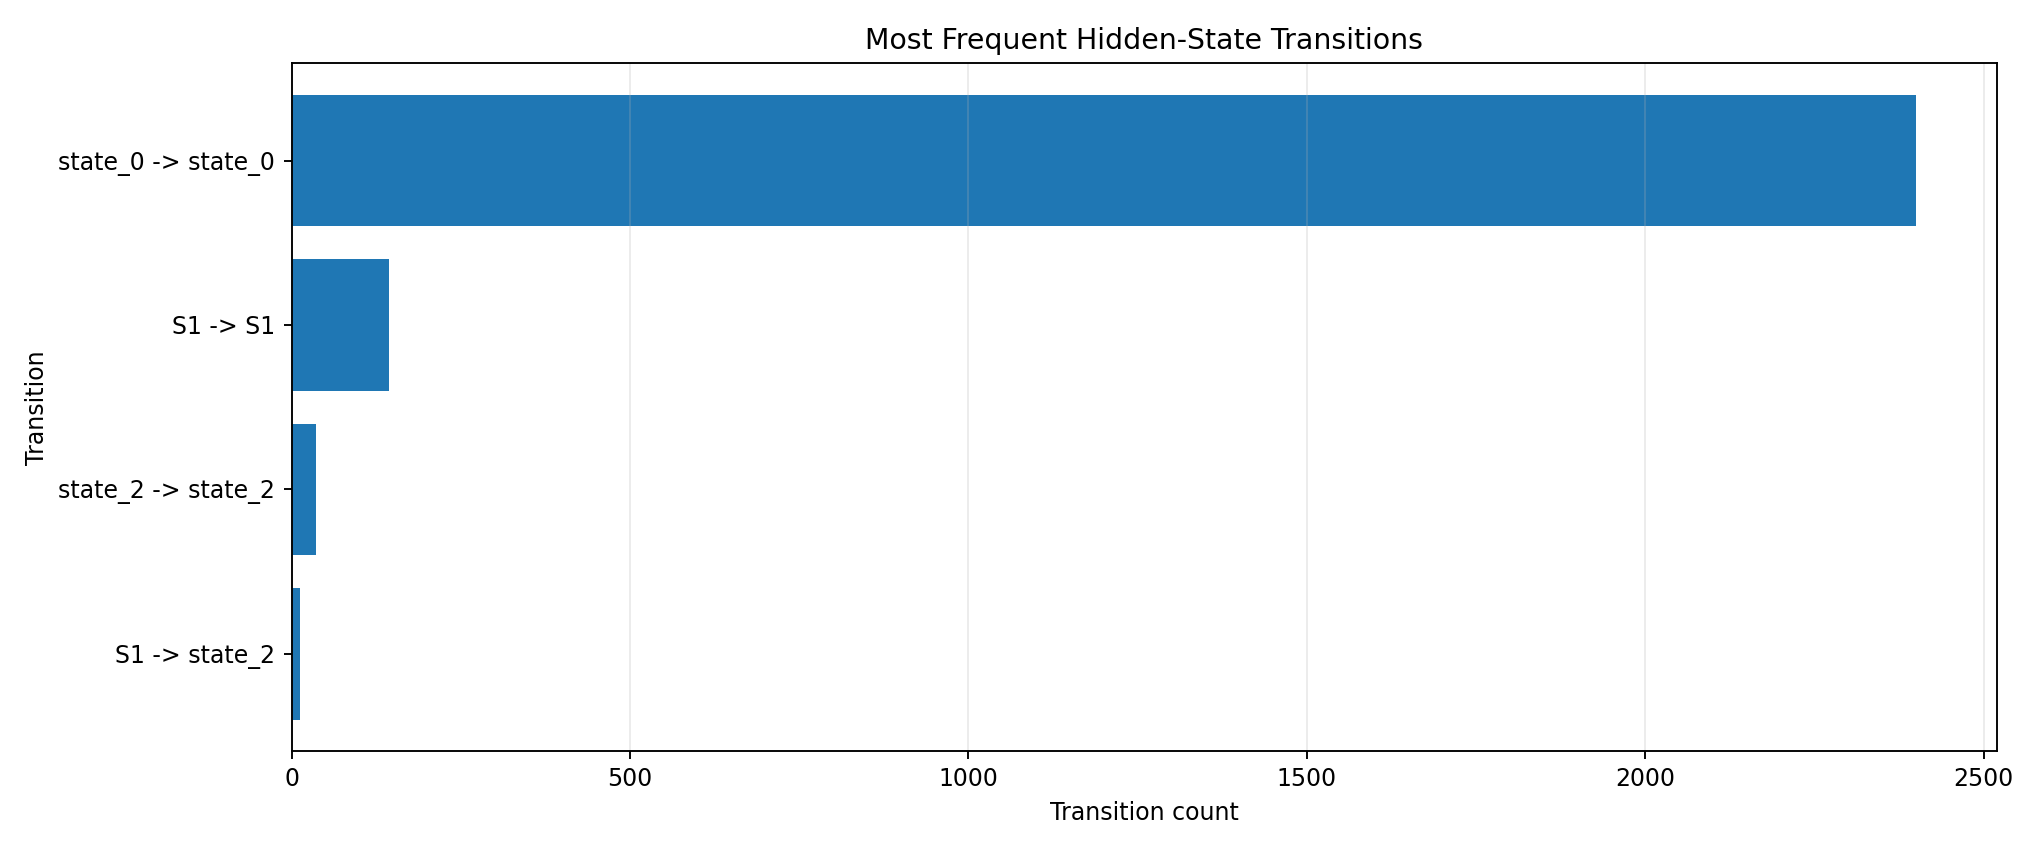

### scenario_success_frequencies

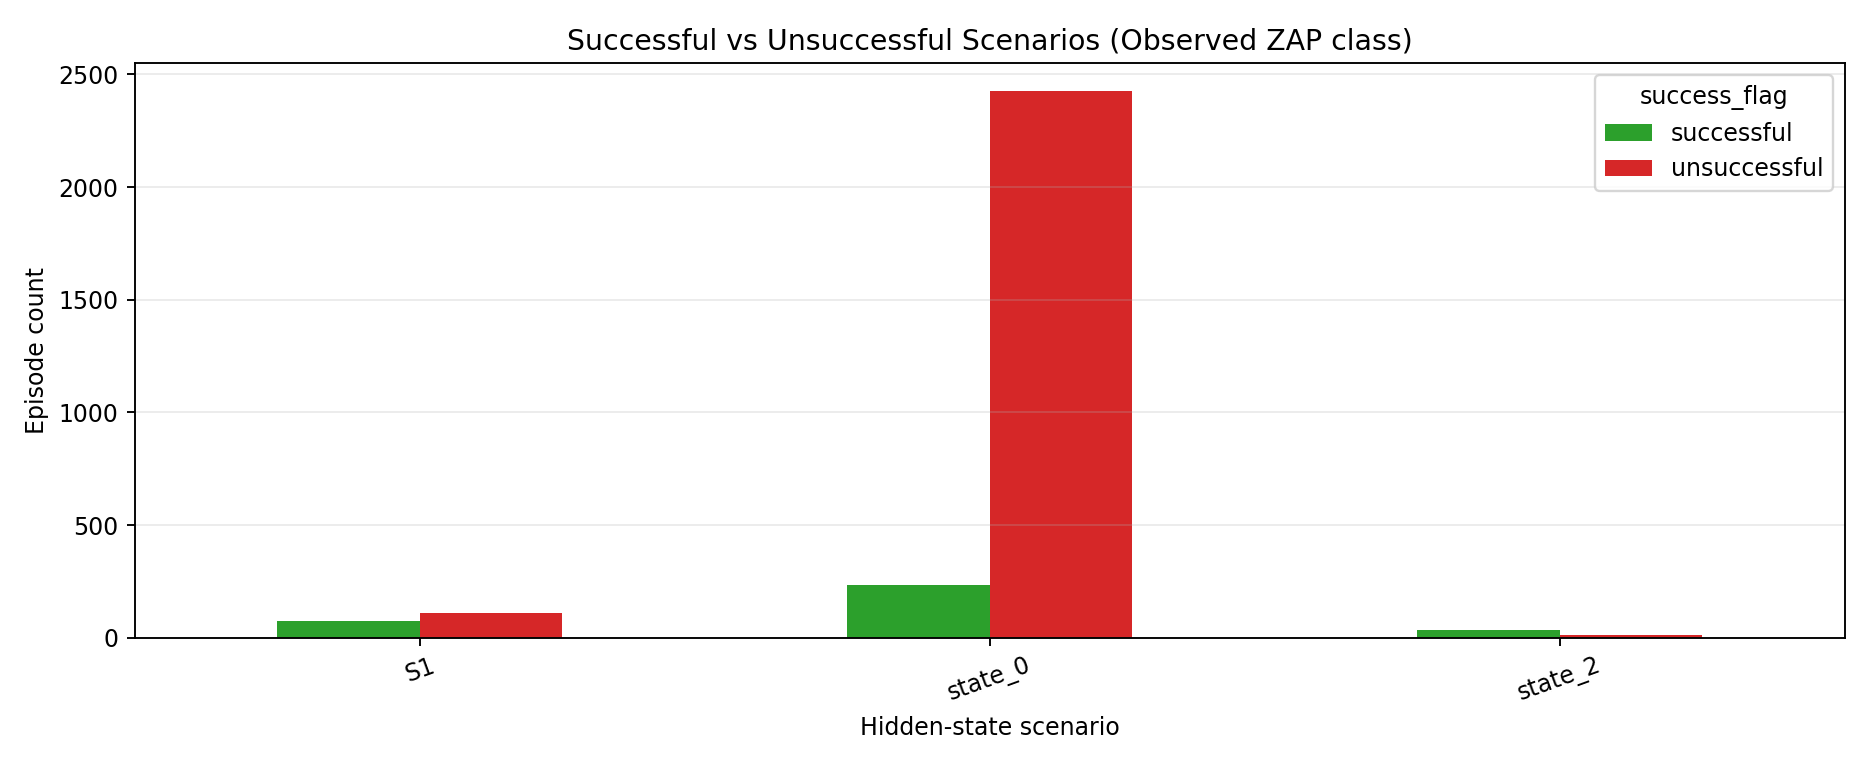

### athlete_comparative_profile

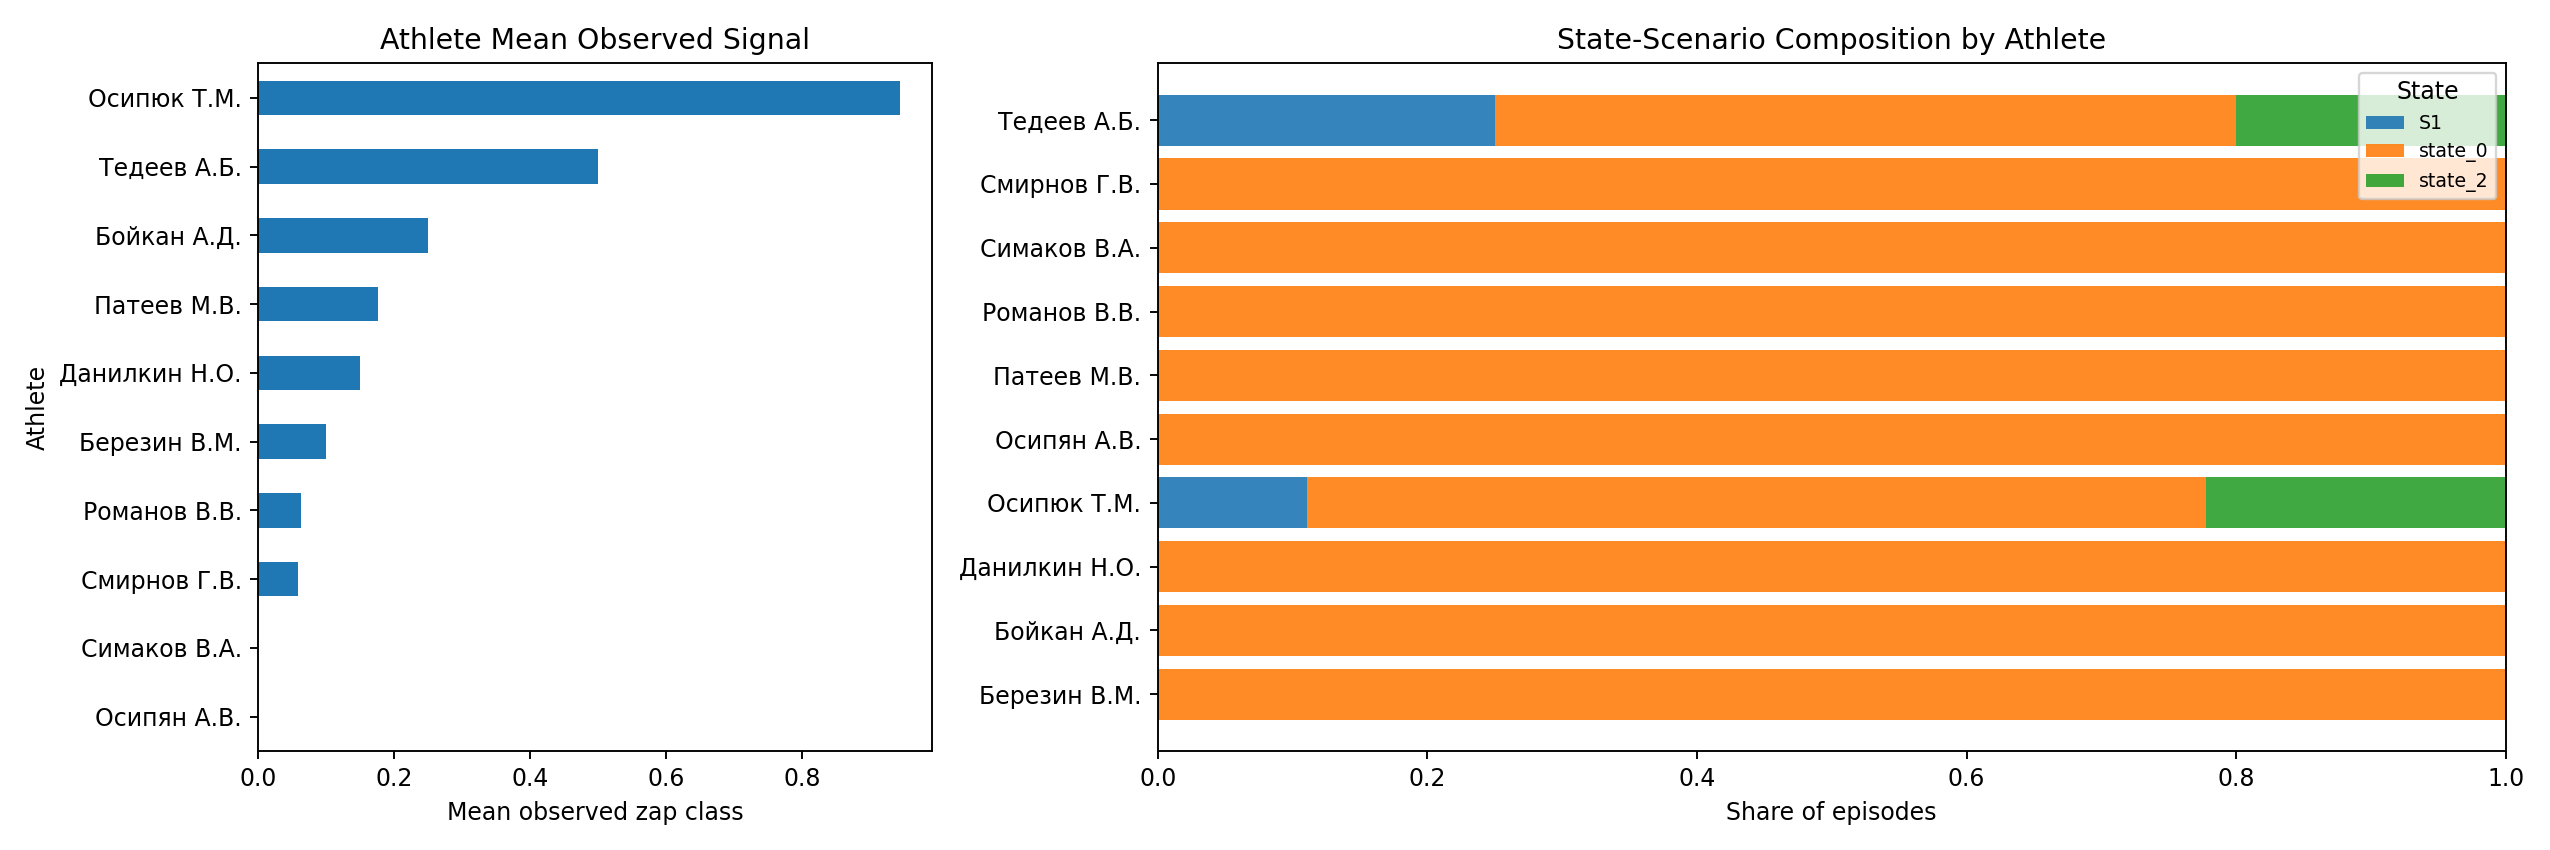

In [7]:
display_inverse_plots(artifacts.plot_paths)


In [8]:
if not artifacts.episode_analysis.empty:
    preview_cols = [
        c
        for c in [
            "episode_id",
            "sequence_id",
            "observed_zap_class",
            "hidden_state_name",
            "confidence",
        ]
        if c in artifacts.episode_analysis.columns
    ]
    display(artifacts.episode_analysis[preview_cols].head(20))
else:
    print("episode_analysis.csv is missing or empty")


,episode_id,sequence_id,observed_zap_class,hidden_state_name,confidence
0,1,48::Акрамов Б.Б.::w=::opp=::tour=::date=::bloc...,zap_r,state_0,0.999963
1,2,48::Акрамов Б.Б.::w=::opp=::tour=::date=::bloc...,no_score,state_0,0.999943
2,3,48::Акрамов Б.Б.::w=::opp=::tour=::date=::bloc...,no_score,state_0,0.999910
3,4,48::Акрамов Б.Б.::w=::opp=::tour=::date=::bloc...,no_score,state_0,0.999855
4,1,48::Рузанов А.О.::w=::opp=::tour=::date=::bloc...,no_score,S1,0.914417
5,2,48::Рузанов А.О.::w=::opp=::tour=::date=::bloc...,no_score,S1,0.853164
6,3,48::Рузанов А.О.::w=::opp=::tour=::date=::bloc...,zap_n,S1,0.778113
7,4,48::Рузанов А.О.::w=::opp=::tour=::date=::bloc...,unknown,S1,0.599318
8,1,48::Лушников А.О.::w=::opp=::tour=::date=::blo...,no_score,state_0,0.998117
9,2,48::Лушников А.О.::w=::opp=::tour=::date=::blo...,no_score,state_0,0.998116
